---
title: "Economic Impacts of Migration"
---

<!-- You have to develop your own headline structure. -->

## Headline 1

## Headline 2


   Year  total_remittances  number_of_migrants
0  2000       1.052142e+06               83822
1  2005       6.803027e+07              125003
2  2010       4.747469e+07              189847
3  2015       1.035451e+09              236603
4  2020       9.210166e+07              286251
Index(['Year', 'total_remittances', 'number_of_migrants'], dtype='str')

Correlation between Remittances and Migrants: 0.22


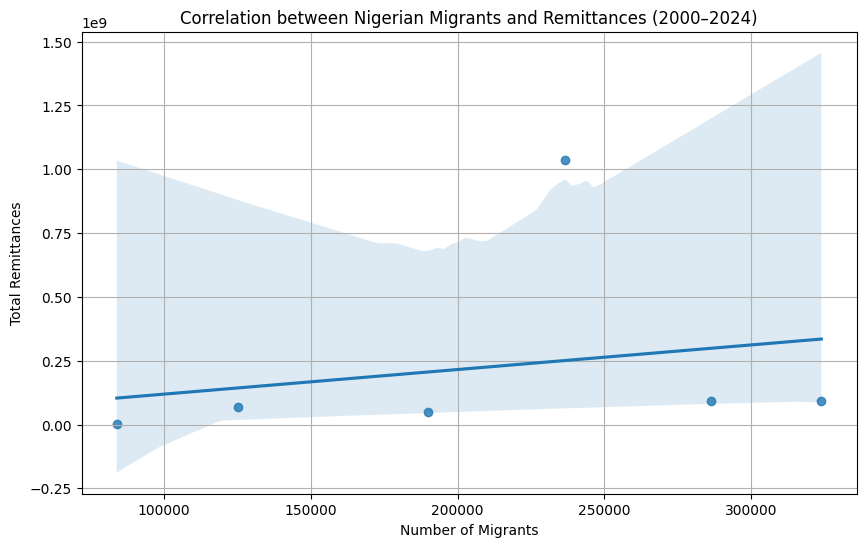

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# File path (your merged dataset)
file_path = r"C:\Users\ZIZIPHO\Desktop\DataScienceLab\Migration\DataScienceLab_Migration-main\data_processed\merged_migration_remittances 1(in).csv"

# Load the merged data
df = pd.read_csv(file_path)

# Inspect data
print(df.head())
print(df.columns)

# Clean column names (strip spaces and convert to lowercase with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Make sure correct data types
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['total_remittances'] = pd.to_numeric(df['total_remittances'], errors='coerce')
df['number_of_migrants'] = pd.to_numeric(df['number_of_migrants'], errors='coerce')

# Drop missing values
df = df.dropna()

# Correlation
correlation = df['total_remittances'].corr(df['number_of_migrants'])
print(f"\nCorrelation between Remittances and Migrants: {correlation:.2f}")

# Plot
plt.figure(figsize=(10, 6))
sns.regplot(
    x=df['number_of_migrants'], 
    y=df['total_remittances'], 
    marker='o'
)

plt.title('Correlation between Nigerian Migrants and Remittances (2000–2024)')
plt.xlabel('Number of Migrants')
plt.ylabel('Total Remittances')
plt.grid(True)
plt.show()

Why the spike in the year remittances in the year 2015?
The oil price collapse in 2014‑2015 created economic pressure in Nigeria, which in migration‑remittance studies is often associated with higher remittance flows as migrants send more support home.

(We have to investigate 2015/ look  into literature)

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# data
data = {
    'Year': [2000, 2005, 2010, 2015, 2020],
    'total_remittances': [1.052142e6, 6.803027e7, 4.747469e7, 1.035451e9, 9.210166e7],
    'number_of_migrants': [83822, 125003, 189847, 236603, 286251]
}

df = pd.DataFrame(data)

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Scale 'total_remittances' and 'number_of_migrants'
df_scaled = df.copy()
df_scaled[['total_remittances', 'number_of_migrants']] = scaler.fit_transform(
    df[['total_remittances', 'number_of_migrants']]
)

# Calculate Policy Index (equal weights)
df_scaled['Policy_Index'] = df_scaled[['total_remittances', 'number_of_migrants']].mean(axis=1)

# Display the results
print(df_scaled)

   Year  total_remittances  number_of_migrants  Policy_Index
0  2000           0.000000            0.000000      0.000000
1  2005           0.064751            0.203434      0.134093
2  2010           0.044879            0.523764      0.284321
3  2015           1.000000            0.754739      0.877369
4  2020           0.088022            1.000000      0.544011
